In [9]:
"""
    Rotary Positional Embeddings

Generally what we do to encode both semantic and the positional meaning we add the token and positional embedding together
This is not ideal as we are affecting the semantic data of token embeddings also changing the magnitude of the vector as well.
The intuition behind RoPE is that:
1. Instead of adding injecting the positional information to the token embedding why dont we inject it in the query or key vector.
2. Instead of adding another vector and forming a new vector why don't we rotate the query or key vector to inject the positional information.

This rotation preserves magnitude or Norm Preservation, ||R(theta)x|| = ||x||

Lets take the query and key vectors and apply the sinusoidal positional embedding to them
I am rotating the vectors by theta
theta = freq * position
=> theta = p / 10000^(2i/d)

Here, 
position of the token -> [1, context_size]
index group of the vector -> [1, embedding dimension]
d -> embedding dimension (fixed)

say I have the query vector of len 4
q = x1 x2 x3 x4
we have to compare groups of 2 so, rotation between x1, x2 with i=0 and the rotation between x3, x4 with i=1 and so on ...
position encoded q = x1' x2' x3' x4'

theta directly proportional to position and inversly proportional to index. Larger position -> larger angle and Larger dimension index -> smaller frequency -> slower rotation
so, 
Lower dimensions -> encode long-range info
Higher dimensions -> encode short-range patterns

in matrix terms,
[x1'] = Ri . [x1]  
[x2']        [x2]

where, Ri = [cos(wip) sin(wip)]
            [-sin(wip) cos(wip)]

            and wi = 1/ 10000^(2i/d)

STEP 1: Angle definition
theta(p, i) = p / 10000^(2i/d)

STEP 2: Pairwise Rotation
q = [x1 x2 x3 x4]
we group, 
i=0 -> (x1 x2) and i=1 -> (x3 x4)

for pair i,
[x1'] = Ri . [x1]  
[x2']        [x2]

=> [x1'] = [x1cos(theta) - x2sin(theta)]  
   [x2']   [x1sin(theta) + x2cos(theta)]

"""
import torch
import matplotlib.pyplot as plt

# Parameters
DIM = 64          # must be even
SEQ_LEN = 200
BASE = 10000
FREQ_TO_PLOT = 0  # which frequency index to visualize

def get_inv_freq(dim, base=10000):
    # Calculating the w(i) value
    n_pairs = dim // 2 # Number of pairs
    i = torch.arange(n_pairs, dtype=torch.float32) # vector of pairs
    return 1.0/(base ** (i/n_pairs))

def get_angles(seq_len, inv_freq):
    pos = torch.arange(seq_len, dtype=torch.float32)
    return torch.outer(pos, inv_freq)

def apply_rope(x, inv_freq):
    # x shape: (batch, seq_len, dim)
    B, L, D = x.shape
    n_pairs = D // 2
    angles = get_angles(L, inv_freq)

    sin = torch.sin(angles)[None, :, :]
    cos = torch.cos(angles)[None, :, :] 

    x1 = x[..., :n_pairs]
    x2 = x[..., n_pairs:]

    rot1 = x1 * cos - x2 * sin
    rot2 = x1 * sin + x2 * cos

    return torch.cat([rot1, rot2], dim=-1)
    

Shape of the inv_freq= torch.Size([32])
shape of the angles= torch.Size([200, 32]) with tokens= 200 and pairs for rotation= 32
Sine shape= torch.Size([1, 200, 32]) and cos shape= torch.Size([1, 200, 32])
Shape of x vector= torch.Size([1, 200, 64])
Half of x vector: torch.Size([1, 200, 32])
Shape of rotated x1 vector= torch.Size([1, 200, 32])
Shape of final rotated x= torch.Size([1, 200, 64])


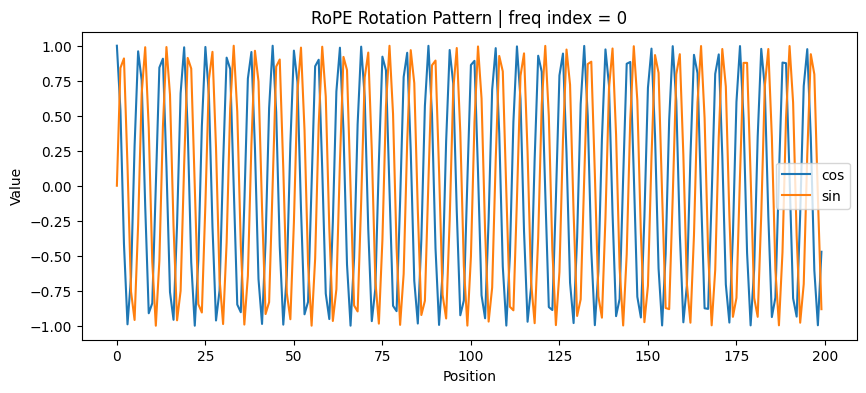

In [22]:
inv_freq = get_inv_freq(DIM, BASE)
print(f"Shape of the inv_freq= {inv_freq.shape}")
angles = get_angles(SEQ_LEN, inv_freq)
print(f"shape of the angles= {angles.shape} with tokens= 200 and pairs for rotation= 32")
# 200 tokens with 32 pairs of angles associated with them
sin = torch.sin(angles).unsqueeze(0)
cos = torch.cos(angles).unsqueeze(0)
print(f"Sine shape= {sin.shape} and cos shape= {cos.shape}")
x = torch.randn(1, SEQ_LEN, DIM)
x1 = x[..., :DIM//2]
x2 = x[..., DIM//2:]
print(f"Shape of x vector= {x.shape}")
print(f"Half of x vector: {x1.shape}")
rot1 = x1 * cos - x2 * sin
rot2 = x1 * sin + x2 * cos
print(f"Shape of rotated x1 vector= {rot1.shape}")
rotated_x = torch.cat([rot1, rot2], dim=-1)
print(f"Shape of final rotated x= {rotated_x.shape}")

theta = angles[:, FREQ_TO_PLOT]

plt.figure(figsize=(10,4))
plt.plot(torch.cos(theta).numpy(), label="cos")
plt.plot(torch.sin(theta).numpy(), label="sin")

plt.title(f"RoPE Rotation Pattern | freq index = {FREQ_TO_PLOT}")
plt.xlabel("Position")
plt.ylabel("Value")
plt.legend()
plt.show()

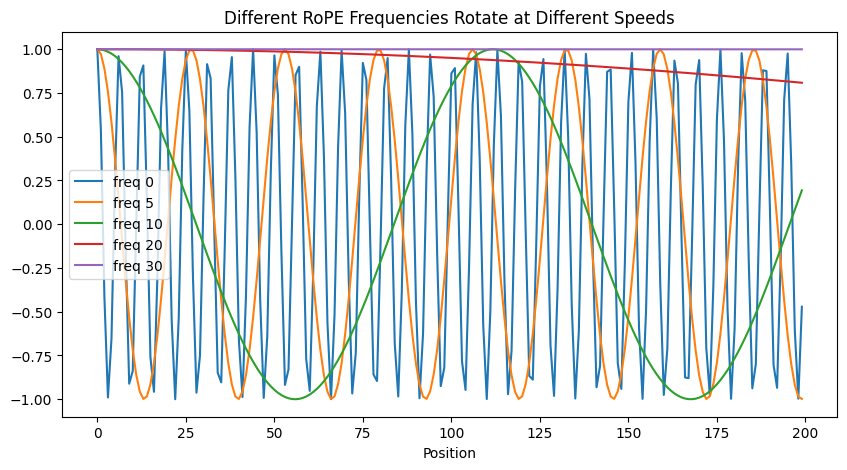

In [20]:
plt.figure(figsize=(10,5))

# Freq should decrease as index increases (inversly proportional)
for i in [0, 5, 10, 20, 30]:
    if i < DIM//2:
        theta = angles[:, i]
        plt.plot(torch.cos(theta).numpy(), label=f"freq {i}")

plt.title("Different RoPE Frequencies Rotate at Different Speeds")
plt.xlabel("Position")
plt.legend()
plt.show()

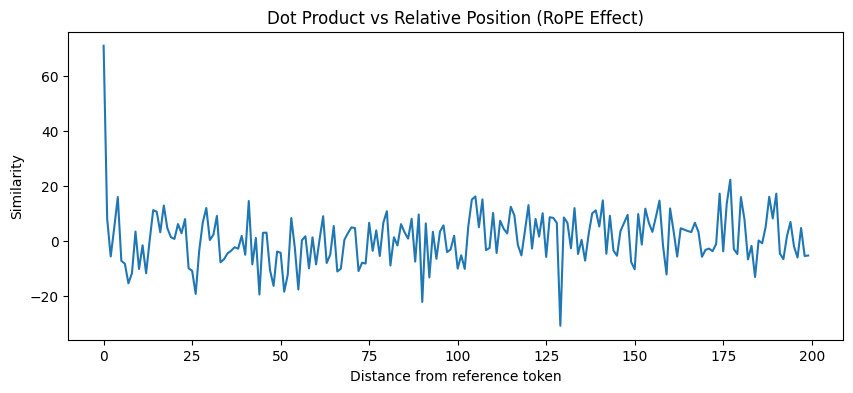

In [7]:
x = torch.randn(1, SEQ_LEN, DIM)
inv_freq = get_inv_freq(DIM, BASE)
rope_x = apply_rope(x, inv_freq)
reference = rope_x[0, 0]

dots = [torch.dot(reference, rope_x[0, i]).item() for i in range(SEQ_LEN)]

plt.figure(figsize=(10,4))
plt.plot(dots)

plt.title("Dot Product vs Relative Position (RoPE Effect)")
plt.xlabel("Distance from reference token")
plt.ylabel("Similarity")
plt.show()